# **Finding Duplicates Lab**

Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.

## Objectives

After completing this lab, you will be able to:

-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.

##### Setup: Install Required Libraries

In [1]:
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn

##### Import Necessary Modules:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks

<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>

The functions below will download the dataset into your browser:

In [ ]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
df.head()

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.

In [4]:
# Display basic information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB
None


In [5]:
# Display summary statistics
print(df.describe())

         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65447.000000   3.374000e+04  29659.000000    29325.000000   
mean   32714.001528  2.963841e+145     11.467143       18.580460   
std    18893.063225  5.444117e+147      9.168610       25.966005   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16352.500000   6.000000e+04      4.000000        0.000000   
50%    32714.000000   1.100000e+05      9.000000       10.000000   
75%    49075.500000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29394.000000    29412.000000    29451.000000    29449.000000   
mean         7.521884       10.060515       24.342405       22.964440   
std         18.422399       21.833543       27.089272       27.017612   
min          0.000000        0.000000        0.000000        0.000000   
25%          0.000000 

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.

In [6]:
# Identify missing values in all columns
print(df.isnull().sum())

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).

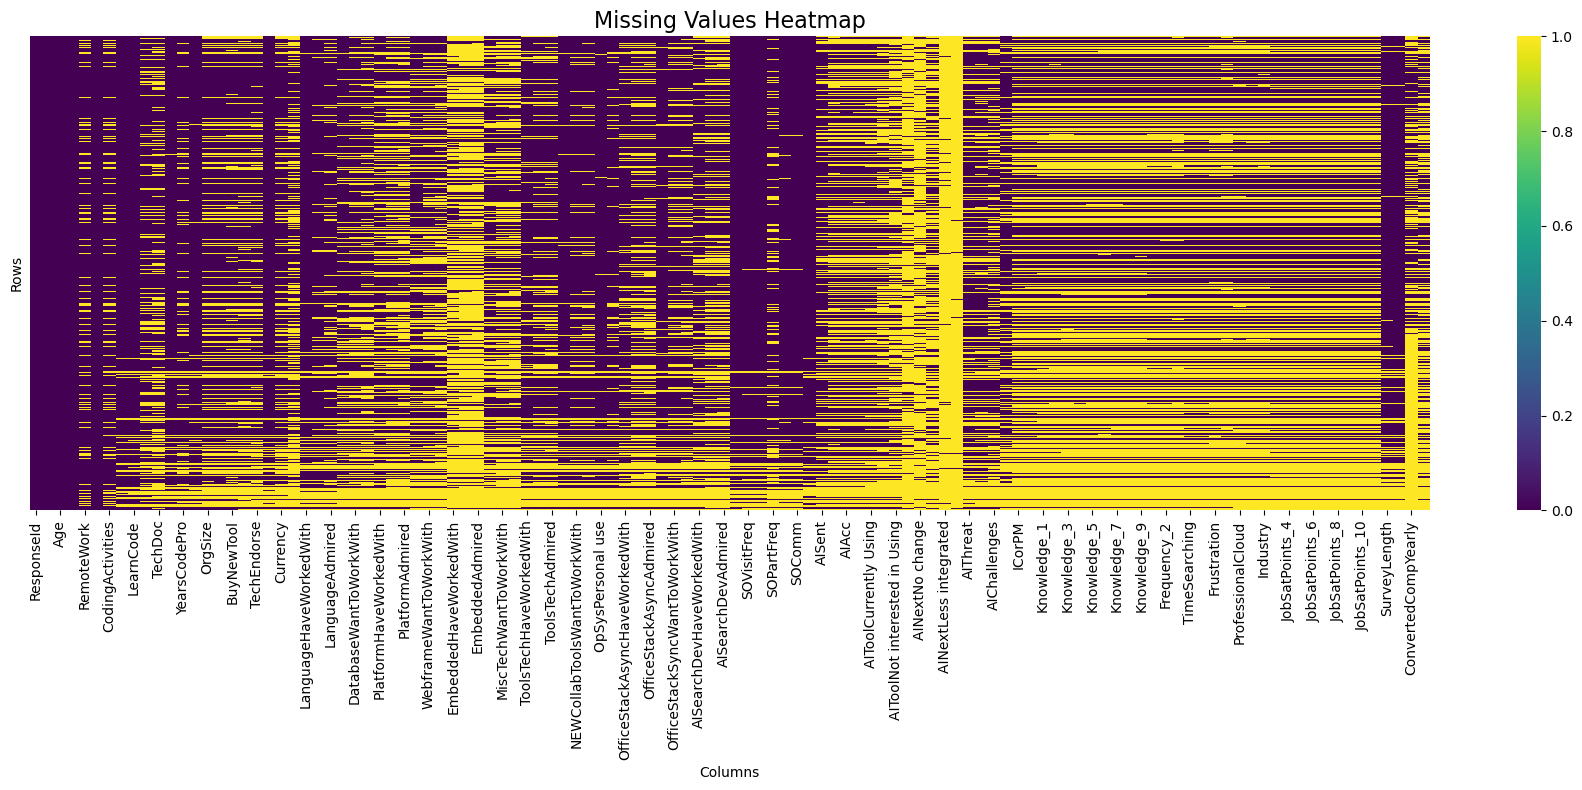

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing values
plt.figure(figsize=(18,8))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=True,
    cmap='viridis'
)

plt.title('Missing Values Heatmap', fontsize=16)
plt.xlabel('Columns')
plt.ylabel('Rows')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).

In [9]:
# Count missing values in Employment column
print(df['Employment'].isnull().sum())

0


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).

In [11]:
# Find the most frequent value in Employment column
most_frequent = df['Employment'].mode()[0]

print(most_frequent)

Employed, full-time


##### Task 6: Impute missing values in the `Employment` column with the most frequent value.

In [12]:
# Impute missing values in Employment column
most_frequent = df['Employment'].mode()[0]

df['Employment'] = df['Employment'].fillna(most_frequent)

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).

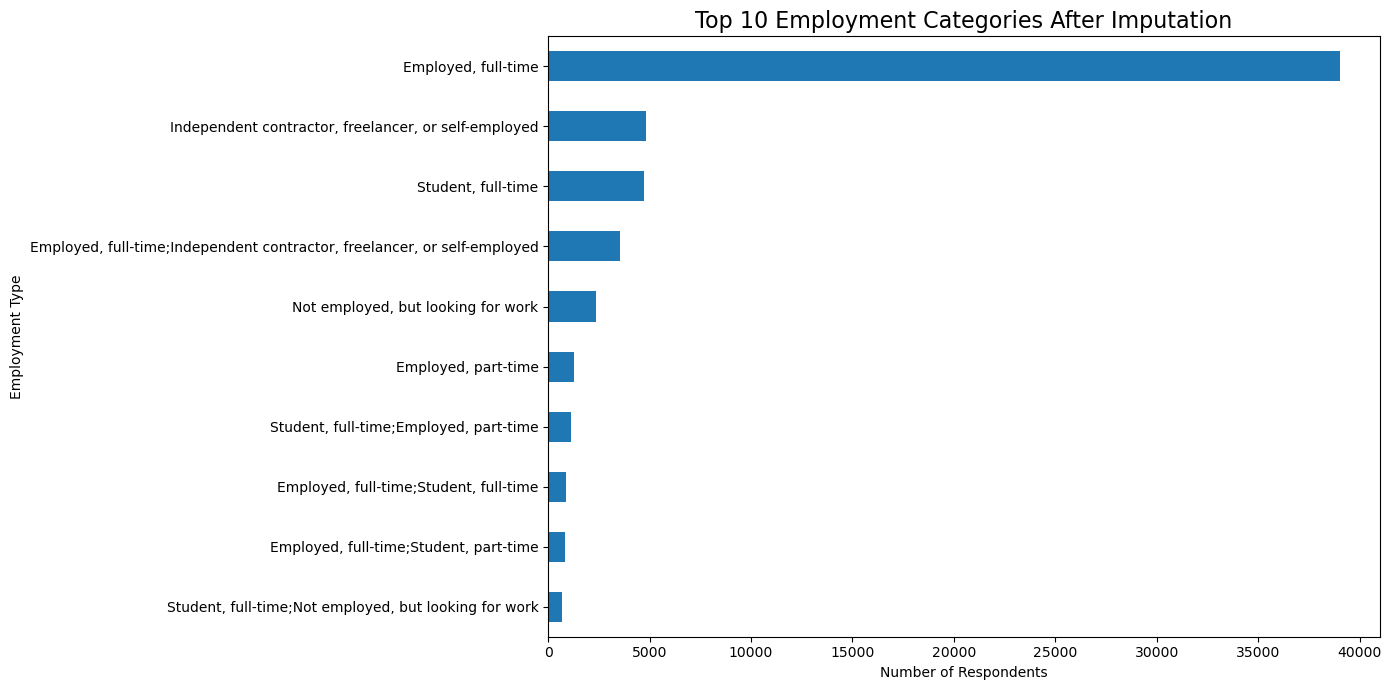

In [15]:
# Visualize Employment distribution after imputation

plt.figure(figsize=(14,7))

(
    df['Employment']
    .value_counts()
    .head(10)
    .sort_values()
    .plot(kind='barh')
)

plt.title('Top 10 Employment Categories After Imputation', fontsize=16)
plt.xlabel('Number of Respondents')
plt.ylabel('Employment Type')

plt.tight_layout()
plt.show()

### Summary

In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.